In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import units as u
from astropy.modeling.models import BlackBody
from scipy.interpolate import interp1d
from synphot.models import BlackBody1D
from synphot import SourceSpectrum

### Creating the model

In [2]:
def create_ring(a1, b1, ecc, inc, ring_ratio, width, height):
    array = np.zeros((height, width), dtype=np.float32)
    
    x0 = width // 2
    y0 = height // 2
    
    inc_rad = np.radians(inc)
    cos_inc = np.cos(-inc_rad)  # negative sign to invert the angle
    sin_inc = np.sin(-inc_rad)  
    
    def transform(x, y, x0, y0, cos_inc, sin_inc):
        norm_x = x - x0
        norm_y = y - y0
        transformed_x = norm_x * cos_inc - norm_y * sin_inc
        transformed_y = norm_x * sin_inc + norm_y * cos_inc
        return transformed_x, transformed_y

    # Outer ellipse
    for y in range(height):
        for x in range(width):
            transformed_x, transformed_y = transform(x, y, x0, y0, cos_inc, sin_inc)
            if transformed_x**2 / (a1**2 * (1 - ecc**2)) + transformed_y**2 / (b1**2) <= 1:
                dist = np.sqrt((x - x0)**2 + (y - y0)**2)
                intensity = 1e-10 * np.exp(-dist**2 / (2 * (0.1 * width)**2))
                array[y, x] = intensity
    
    # Inner ellipse
    a2 = a1 * ring_ratio
    b2 = b1 * ring_ratio
    
    for y in range(height):
        for x in range(width):
            transformed_x, transformed_y = transform(x, y, x0, y0, cos_inc, sin_inc)
            if transformed_x**2 / (a2**2 * (1 - ecc**2)) + transformed_y**2 / (b2**2) <= 1:
                array[y, x] = 0
    
    return array

In [3]:
width, height = 2000, 2000
ring1 = create_ring(720, 490, 0.3, 40, 0.96, width, height) #B7
ring2 = create_ring(650, 450, 0.3, 40, 0.93, width, height) #B6
ring3 = create_ring(560, 400, 0.3, 40, 0.97, width, height) #B5
ring4 = create_ring(490, 348, 0.3, 40, 0.9, width, height) #B4
ring5 = create_ring(440, 313, 0.3, 40, 0.8, width, height) #B3
ring6 = create_ring(352, 250, 0.3, 40, 0.7, width, height) #B2
ring7 = create_ring(200, 150, 0.3, 40, 0.45, width, height) #B1

In [4]:
hl_tauri_rings = ring1 + ring2 + ring3 + ring4 + ring5 + ring6 + ring7

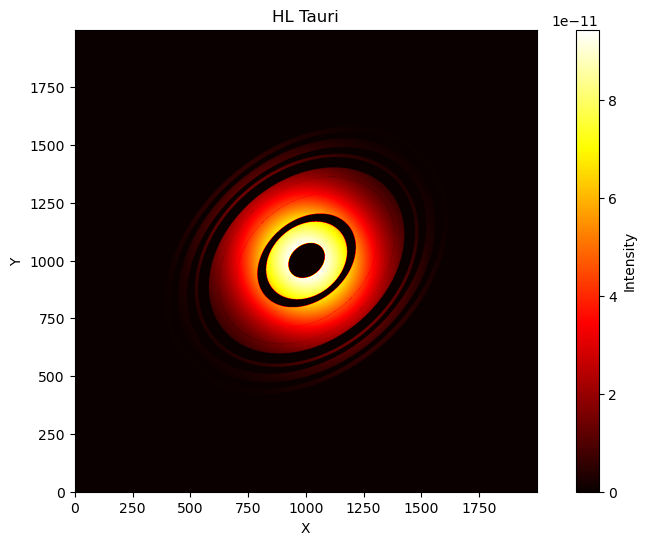

In [5]:
plt.figure(figsize=(10, 6))
plt.imshow(hl_tauri_rings, cmap='hot', origin='lower')
plt.title('HL Tauri')
plt.xlabel('X')
plt.ylabel('Y')
cbar = plt.colorbar()
cbar.set_label('Intensity')
plt.show()

### Creating a source object

In [6]:
import scopesim as sim
from astropy import units as u
from scopesim.source import source_templates as sim_tp
from astropy.io import fits
from matplotlib.colors import LogNorm
from astropy.wcs import WCS

In [7]:
src_star = sim_tp.star(flux=10*u.ABmag)

In [8]:
filename = 'ring1.fits'
hdu1 = fits.PrimaryHDU(ring1)
hdu1.writeto(filename, overwrite=True)

In [9]:
filename = 'ring2.fits'
hdu2 = fits.PrimaryHDU(ring2)
hdu2.writeto(filename, overwrite=True)

In [10]:
filename = 'ring3.fits'
hdu3 = fits.PrimaryHDU(ring3)
hdu3.writeto(filename, overwrite=True)

In [11]:
filename = 'ring4.fits'
hdu4 = fits.PrimaryHDU(ring4)
hdu4.writeto(filename, overwrite=True)

In [12]:
filename = 'ring5.fits'
hdu5 = fits.PrimaryHDU(ring5)
hdu5.writeto(filename, overwrite=True)

In [13]:
filename = 'ring6.fits'
hdu5 = fits.PrimaryHDU(ring6)
hdu5.writeto(filename, overwrite=True)

In [14]:
filename = 'ring7.fits'
hdu5 = fits.PrimaryHDU(ring7)
hdu5.writeto(filename, overwrite=True)

In [15]:
hdul1 = fits.open('ring1.fits') 
hdul1[0].data /= hdul1[0].data.max()
hdul1[0].header["CDELT1"] = (0.0057 / 3600)    
hdul1[0].header["CDELT2"] = (0.0057 / 3600)    
hdul1[0].header["CRVAL1"] = 0
hdul1[0].header["CRVAL2"] = 0
hdul1[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul1[0].header["CRPIX2"] = 1000.5
hdul1[0].header["CUNIT1"] = "deg"
hdul1[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*5e-11

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring1 = sim.Source(image_hdu=hdul1[0], spectra=emission_raw)

In [16]:
hdul2 = fits.open('ring2.fits') 
hdul2[0].data /= hdul2[0].data.max()
hdul2[0].header["CDELT1"] = (0.0057 / 3600)   #CD1_1 
hdul2[0].header["CDELT2"] = (0.0057 / 3600)   #CD2_2 #für metis 0.0057 / 3600
hdul2[0].header["CRVAL1"] = 0
hdul2[0].header["CRVAL2"] = 0
hdul2[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul2[0].header["CRPIX2"] = 1000.5
hdul2[0].header["CUNIT1"] = "deg"
hdul2[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*7e-11

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring2 = sim.Source(image_hdu=hdul2[0], spectra=emission_raw)

In [17]:
hdul3 = fits.open('ring3.fits') 
hdul3[0].data /= hdul3[0].data.max()
hdul3[0].header["CDELT1"] = (0.0057 / 3600)   #CD1_1 
hdul3[0].header["CDELT2"] = (0.0057 / 3600)   #CD2_2 #für metis 0.0057 / 3600
hdul3[0].header["CRVAL1"] = 0
hdul3[0].header["CRVAL2"] = 0
hdul3[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul3[0].header["CRPIX2"] = 1000.5
hdul3[0].header["CUNIT1"] = "deg"
hdul3[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*9e-11

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring3 = sim.Source(image_hdu=hdul3[0], spectra=emission_raw)

In [18]:
hdul4 = fits.open('ring4.fits') 
hdul4[0].data /= hdul4[0].data.max()
hdul4[0].header["CDELT1"] = (0.0057 / 3600)   #CD1_1 
hdul4[0].header["CDELT2"] = (0.0057 / 3600)   #CD2_2 #für metis 0.0057 / 3600
hdul4[0].header["CRVAL1"] = 0
hdul4[0].header["CRVAL2"] = 0
hdul4[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul4[0].header["CRPIX2"] = 1000.5
hdul4[0].header["CUNIT1"] = "deg"
hdul4[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*2.5e-10

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring4 = sim.Source(image_hdu=hdul4[0], spectra=emission_raw)

In [19]:
hdul5 = fits.open('ring5.fits') 
hdul5[0].data /= hdul5[0].data.max()
hdul5[0].header["CDELT1"] = (0.0057 / 3600)   #CD1_1 
hdul5[0].header["CDELT2"] = (0.0057 / 3600)   #CD2_2 #für metis 0.0057 / 3600
hdul5[0].header["CRVAL1"] = 0
hdul5[0].header["CRVAL2"] = 0
hdul5[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul5[0].header["CRPIX2"] = 1000.5
hdul5[0].header["CUNIT1"] = "deg"
hdul5[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*3e-10

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring5 = sim.Source(image_hdu=hdul5[0], spectra=emission_raw)

In [20]:
hdul6 = fits.open('ring6.fits') 
hdul6[0].data /= hdul6[0].data.max()
hdul6[0].header["CDELT1"] = (0.0057 / 3600)   #CD1_1 
hdul6[0].header["CDELT2"] = (0.0057 / 3600)   #CD2_2 #für metis 0.0057 / 3600
hdul6[0].header["CRVAL1"] = 0
hdul6[0].header["CRVAL2"] = 0
hdul6[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul6[0].header["CRPIX2"] = 1000.5
hdul6[0].header["CUNIT1"] = "deg"
hdul6[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*3.5e-10

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring6 = sim.Source(image_hdu=hdul6[0], spectra=emission_raw)

In [21]:
hdul7 = fits.open('ring7.fits') 
hdul7[0].data /= hdul7[0].data.max()
hdul7[0].header["CDELT1"] = (0.0057 / 3600)   #CD1_1 
hdul7[0].header["CDELT2"] = (0.0057 / 3600)   #CD2_2 #für metis 0.0057 / 3600
hdul7[0].header["CRVAL1"] = 0
hdul7[0].header["CRVAL2"] = 0
hdul7[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul7[0].header["CRPIX2"] = 1000.5
hdul7[0].header["CUNIT1"] = "deg"
hdul7[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*9e-10 

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring7 = sim.Source(image_hdu=hdul7[0], spectra=emission_raw)

In [22]:
src = src_ring1 + src_ring2 + src_ring3 + src_ring4 + src_ring5 + src_ring6 + src_ring7 + src_star

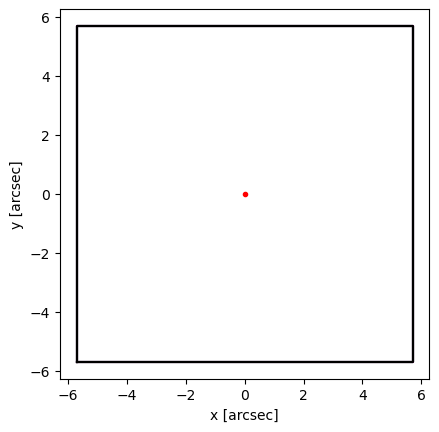

In [23]:
src.plot()

### L Band imaging

In [24]:
cmd_l = sim.UserCommands(use_instrument='METIS', set_modes=['img_lm'], 
                        properties={"!OBS.exptime": 3600})
metis_l = sim.OpticalTrain(cmd_l)
metis_l['skycalc_atmosphere'].include=False
metis_l['detector_linearity'].include=False
metis_l['quantization'].include=False

In [25]:
metis_l.observe(src)
hdus_l = metis_l.readout()

 FOVs: 100%|█████████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.57s/it]
 Image Plane effects: 0it [00:00, ?it/s]

astar.scopesim.detector.detector_array - Extracting from 1 detectors...


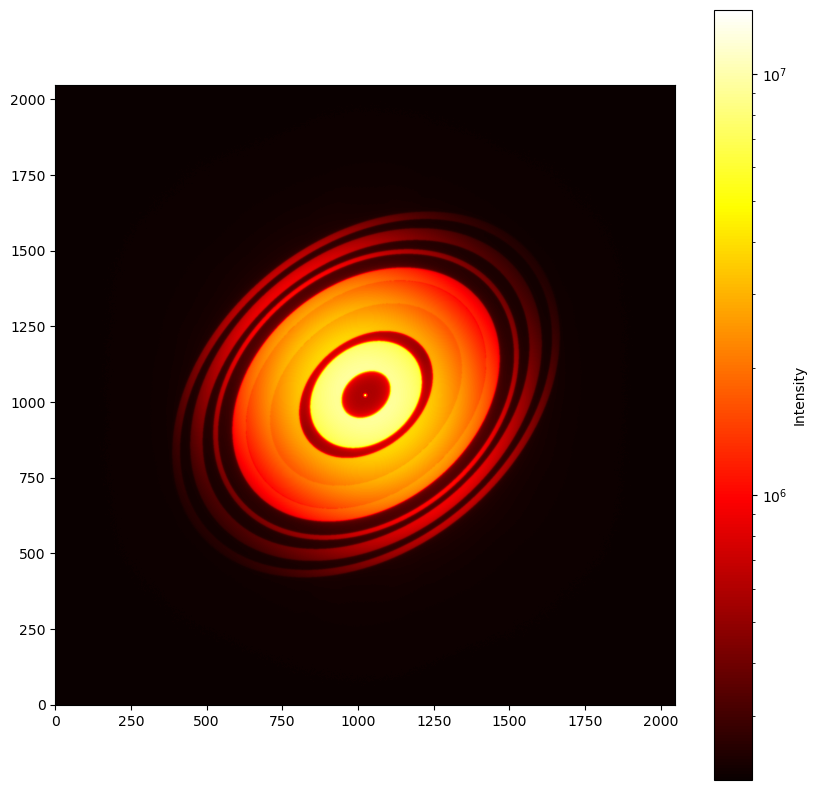

In [26]:
plt.figure(figsize=(10,10))
plt.imshow(hdus_l[0][1].data, norm=LogNorm(), origin='lower', cmap='hot')
cbar = plt.colorbar()
cbar.set_label('Intensity')

### L Band long slit spectroscopy

In [27]:
exptime = 3600.   # seconds
cmd_lss = sim.UserCommands(use_instrument="METIS", set_modes=["lss_l"],
                      properties={"!OBS.dit": 2,
                                  "!OBS.ndit": 1800,
                                 "!SIM.spectral.spectral_resolution": 20000,
                                 "!SIM.spectral.spectral_bin_width": 2e-4,})

metis_lss = sim.OpticalTrain(cmd_lss)

In [28]:
metis_lss.observe(src)
hdus_lss = metis_lss.readout(detector_readout_mode="auto")[0]

 FOV effects:  50%|███████████████████████████████████                                   | 1/2 [00:51<00:51, 51.78s/it]

astar.scopesim.effects.spectral_trace_list_utils - Mapping METIS LSS L



 FOVs: 100%|█████████████████████████████████████████████████████████████████████████████| 1/1 [01:10<00:00, 70.83s/it]
 Image Plane effects: 0it [00:00, ?it/s]

astar.scopesim.effects.electronic - Detector mode set to fast
astar.scopesim.detector.detector_array - Extracting from 1 detectors...


astar.scopesim.effects.electronic - Detector mode set to fast


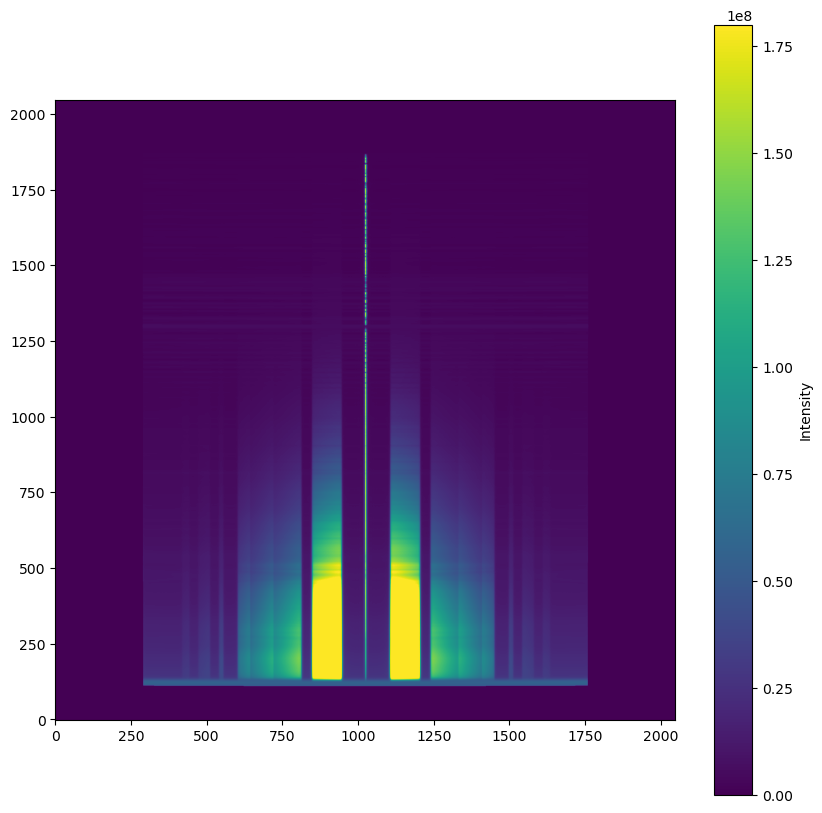

In [29]:
plt.figure(figsize=(10,10))
plt.imshow(hdus_lss[1].data, origin='lower')
cbar = plt.colorbar()
cbar.set_label('Intensity')

In [30]:
sky = sim.source.source_templates.empty_sky()

In [31]:
metis_lss.observe(sky, update=True)
hdus_sky = metis_lss.readout(detector_readout_mode="auto")[0]

 FOV effects:  50%|███████████████████████████████████                                   | 1/2 [00:10<00:10, 10.66s/it]

astar.scopesim.effects.spectral_trace_list_utils - Mapping METIS LSS L



 FOVs: 100%|█████████████████████████████████████████████████████████████████████████████| 1/1 [00:25<00:00, 25.42s/it]
 Image Plane effects: 0it [00:00, ?it/s]

astar.scopesim.effects.electronic - Detector mode set to slow
astar.scopesim.detector.detector_array - Extracting from 1 detectors...


astar.scopesim.effects.electronic - Detector mode set to slow


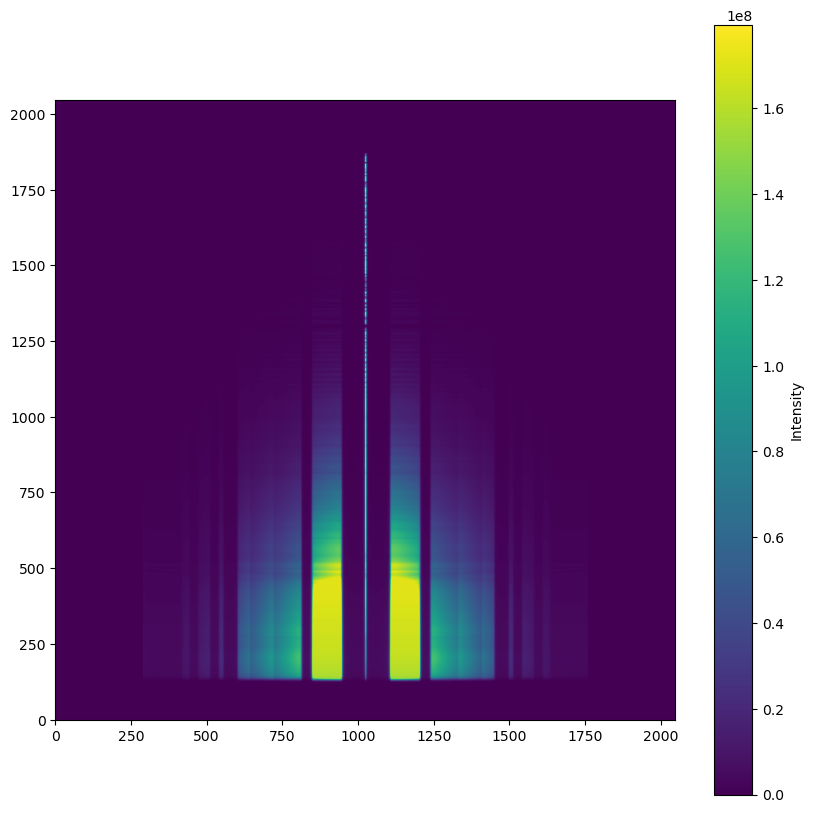

In [32]:
plt.figure(figsize=(10,10))
plt.imshow(hdus_lss[1].data - hdus_sky[1].data, origin='lower')
cbar = plt.colorbar()
cbar.set_label('Intensity')

In [33]:
metis_lss.image_planes[0].data.sum()

4212836923.9253044

In [34]:
hdus_sky[1].data.sum()

15166970923800.092

In [35]:
hdus_lss[1].data.sum()

52762015888303.78

In [36]:
spectrum_l = hdus_lss[1].data - hdus_sky[1].data

Text(0, 0.5, 'relative flux units')

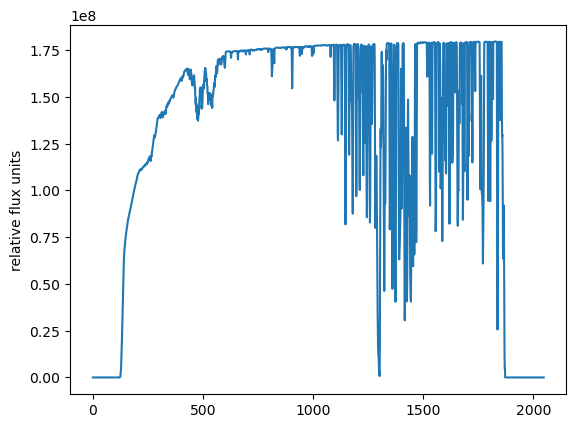

In [37]:
plt.plot(spectrum_l[:,1025]) #Star
plt.ylabel('relative flux units')

Text(0, 0.5, 'relative flux units')

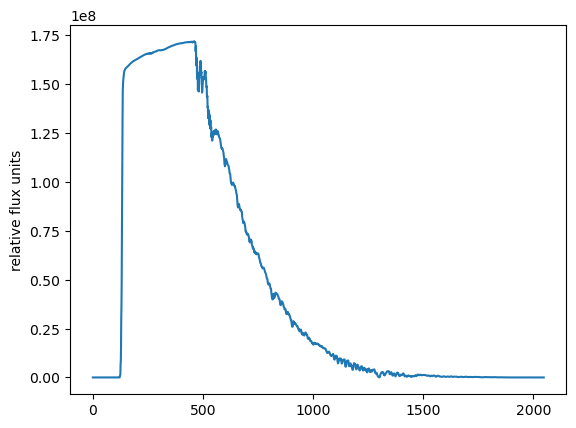

In [38]:
plt.plot(spectrum_l[:,900]) #Ring 7
plt.ylabel('relative flux units')

Text(0, 0.5, 'Flux ()')

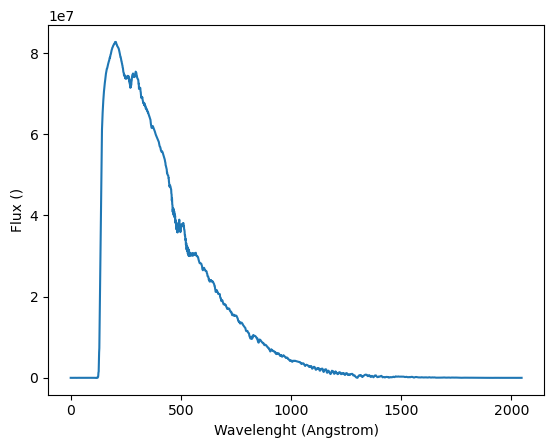

In [39]:
plt.plot(spectrum_l[:,725]) #Ring 6
plt.xlabel('Wavelenght (Angstrom)')
plt.ylabel('Flux ()')

Text(0, 0.5, 'Flux ()')

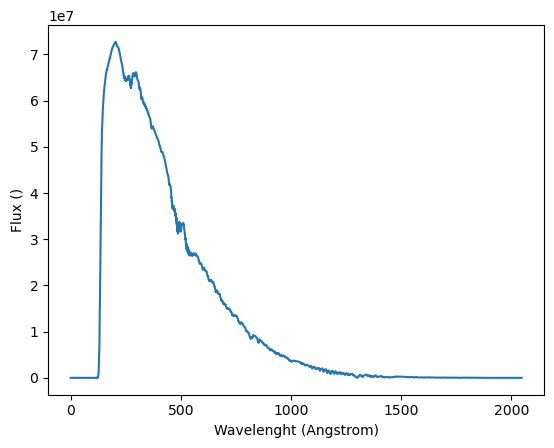

In [40]:
plt.plot(spectrum_l[:,675]) #Ring 5
plt.xlabel('Wavelenght (Angstrom)')
plt.ylabel('Flux ()')

Text(0, 0.5, 'Flux ()')

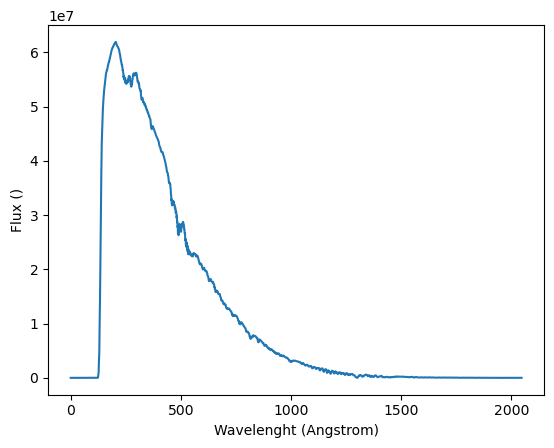

In [41]:
plt.plot(spectrum_l[:,625]) #Ring 4
plt.xlabel('Wavelenght (Angstrom)')
plt.ylabel('Flux ()')

Text(0, 0.5, 'Flux ()')

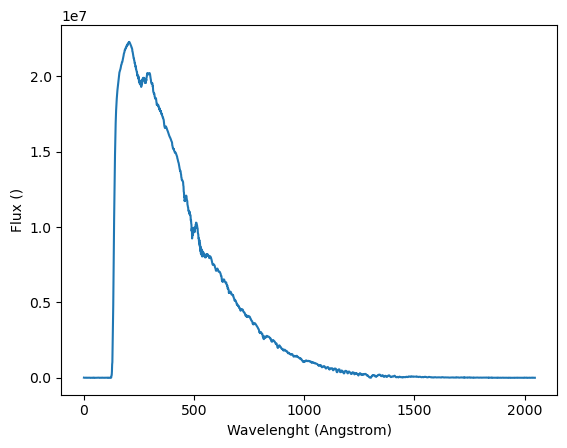

In [42]:
plt.plot(spectrum_l[:,550]) #Ring 3
plt.xlabel('Wavelenght (Angstrom)')
plt.ylabel('Flux ()')

Text(0, 0.5, 'Flux ()')

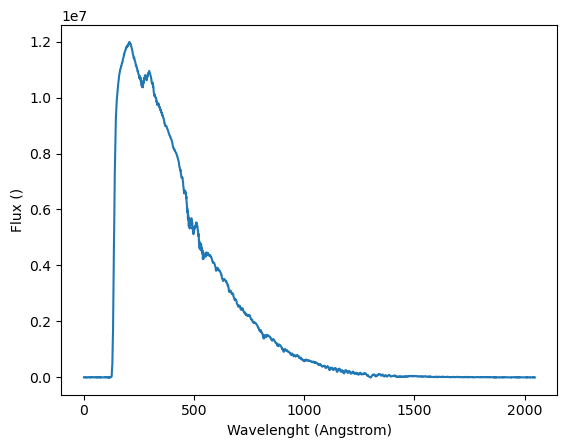

In [43]:
plt.plot(spectrum_l[:,475]) #Ring 2
plt.xlabel('Wavelenght (Angstrom)')
plt.ylabel('Flux ()')

Text(0, 0.5, 'Flux ()')

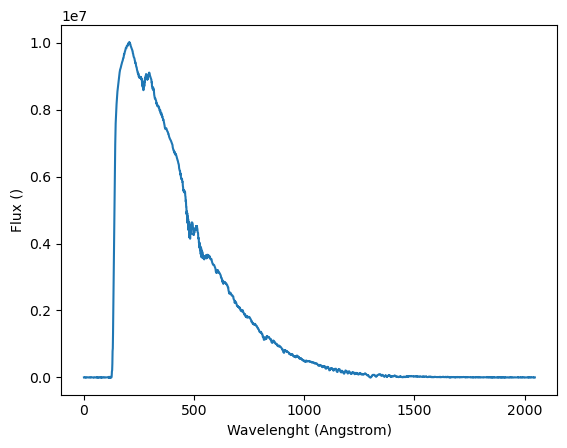

In [44]:
plt.plot(spectrum_l[:,425]) #Ring 1
plt.xlabel('Wavelenght (Angstrom)')
plt.ylabel('Flux ()')

Text(0.5, 1.0, 'Ring 1')

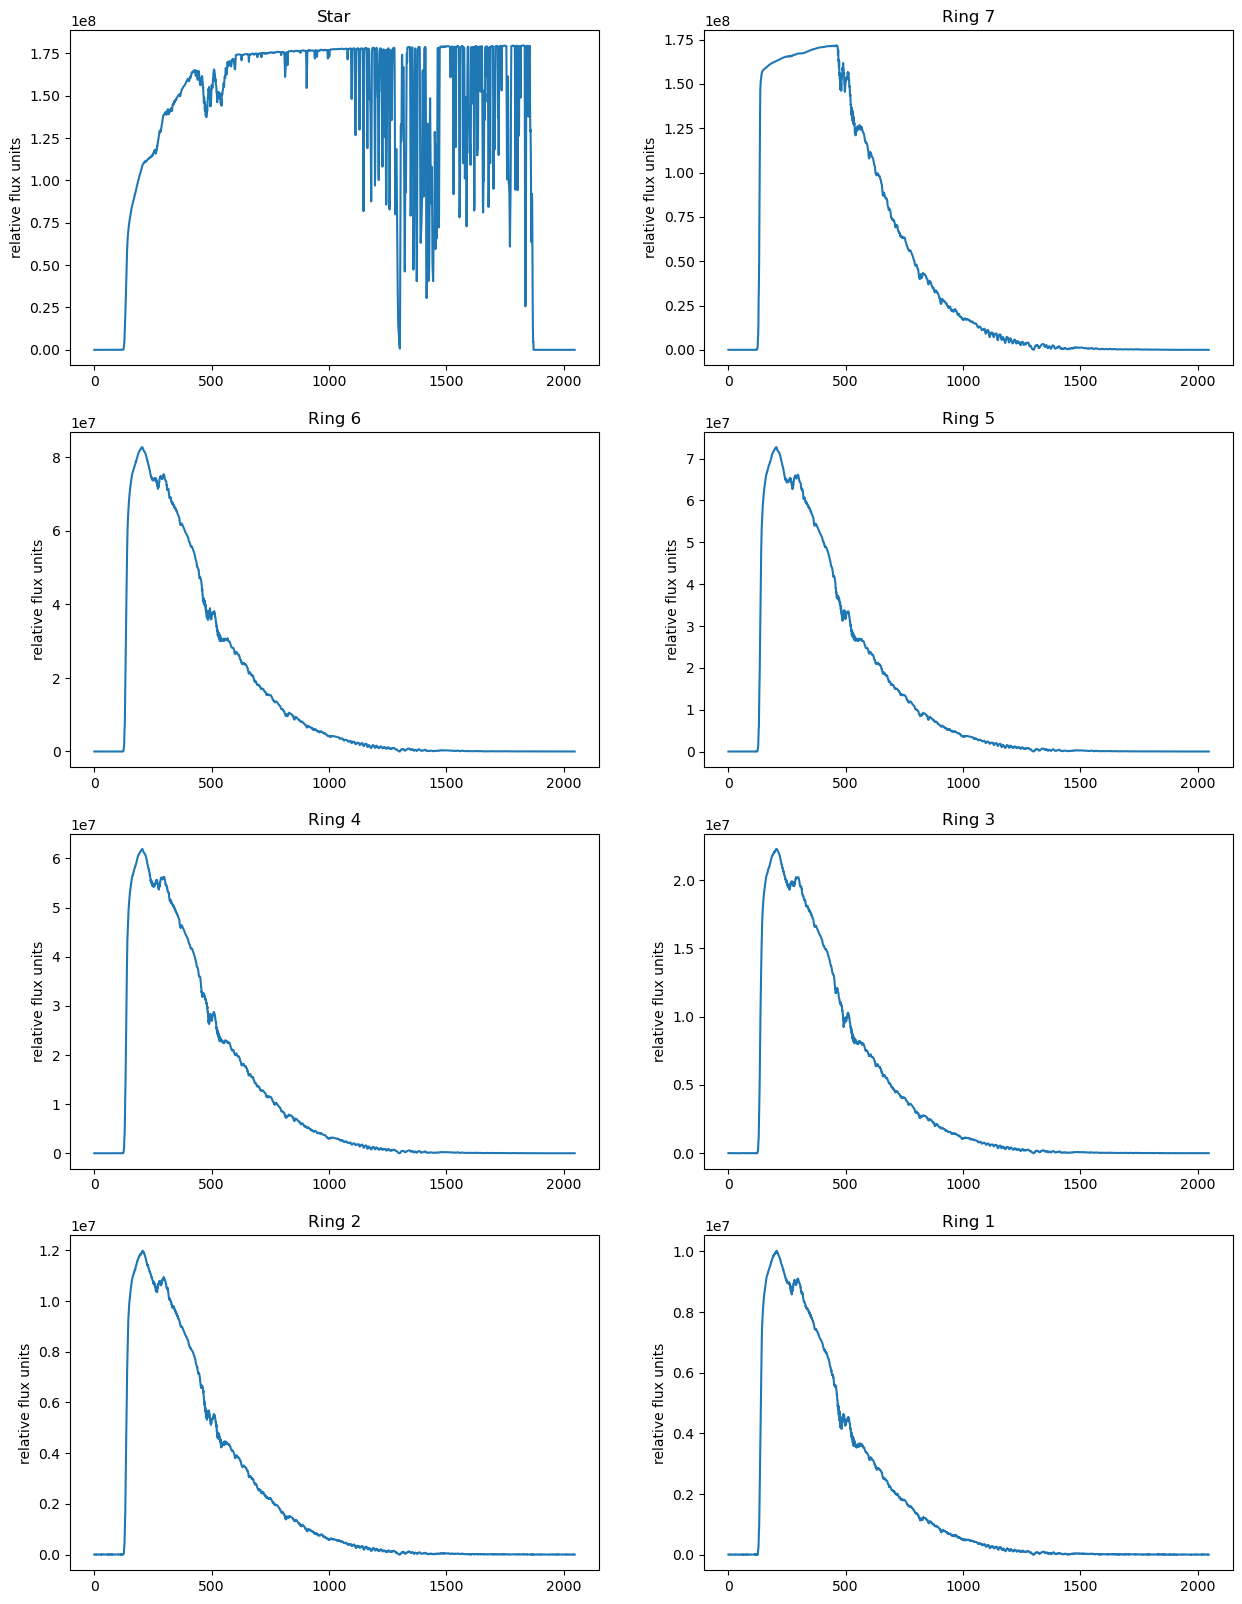

In [45]:
fig, axs = plt.subplots(4, 2, figsize=(15, 20))

axs[0, 0].plot(spectrum_l[:, 1025]) #Star
axs[0, 0].set_ylabel('relative flux units')
axs[0, 0].set_title('Star')

axs[0, 1].plot(spectrum_l[:, 900]) #Ring 7
axs[0, 1].set_ylabel('relative flux units')
axs[0, 1].set_title('Ring 7')

axs[1, 0].plot(spectrum_l[:, 725]) #Ring 6
axs[1, 0].set_ylabel('relative flux units')
axs[1, 0].set_title('Ring 6')

axs[1, 1].plot(spectrum_l[:, 675]) #Ring 5
axs[1, 1].set_ylabel('relative flux units')
axs[1, 1].set_title('Ring 5')

axs[2, 0].plot(spectrum_l[:,625]) #Ring 4
axs[2, 0].set_ylabel('relative flux units')
axs[2, 0].set_title('Ring 4')

axs[2, 1].plot(spectrum_l[:,550]) #Ring 3
axs[2, 1].set_ylabel('relative flux units')
axs[2, 1].set_title('Ring 3')

axs[3, 0].plot(spectrum_l[:,475]) #Ring 2
axs[3, 0].set_ylabel('relative flux units')
axs[3, 0].set_title('Ring 2')

axs[3, 1].plot(spectrum_l[:,425]) #Ring 1
axs[3, 1].set_ylabel('relative flux units')
axs[3, 1].set_title('Ring 1')

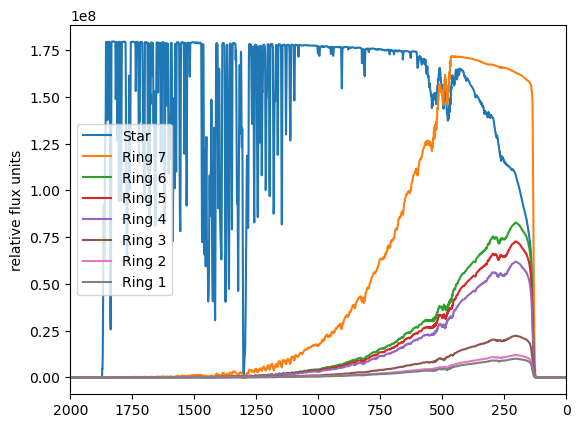

In [46]:
plt.plot(spectrum_l[:, 1025], label='Star')
plt.plot(spectrum_l[:, 900], label='Ring 7')
plt.plot(spectrum_l[:, 725], label='Ring 6')
plt.plot(spectrum_l[:, 675], label='Ring 5')
plt.plot(spectrum_l[:, 625], label='Ring 4')
plt.plot(spectrum_l[:, 550], label='Ring 3')
plt.plot(spectrum_l[:, 475], label='Ring 2')
plt.plot(spectrum_l[:, 425], label='Ring 1')
plt.xlim([2000, 0])
plt.ylabel('relative flux units')
plt.legend(loc='center left')

plt.show()

### IFU Spectroscopy

In [47]:
src_star_lms = sim_tp.star(flux=8*u.ABmag)

In [48]:
hdul1_lms = fits.open('ring1.fits') 
hdul1_lms[0].data /= hdul1_lms[0].data.max()
hdul1_lms[0].header["CDELT1"] = (0.0057 / 3600) / 10  #CD1_1 
hdul1_lms[0].header["CDELT2"] = (0.0057 / 3600) / 10  #CD2_2 #für metis 0.0057 / 3600
hdul1_lms[0].header["CRVAL1"] = 0
hdul1_lms[0].header["CRVAL2"] = 0
hdul1_lms[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul1_lms[0].header["CRPIX2"] = 1000.5
hdul1_lms[0].header["CUNIT1"] = "deg"
hdul1_lms[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*5e-11

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring1_lms = sim.Source(image_hdu=hdul1_lms[0], spectra=emission_raw)

In [49]:
hdul2_lms = fits.open('ring2.fits') 
hdul2_lms[0].data /= hdul2_lms[0].data.max()
hdul2_lms[0].header["CDELT1"] = (0.0057 / 3600) / 10  #CD1_1 
hdul2_lms[0].header["CDELT2"] = (0.0057 / 3600) / 10  #CD2_2 #für metis 0.0057 / 3600
hdul2_lms[0].header["CRVAL1"] = 0
hdul2_lms[0].header["CRVAL2"] = 0
hdul2_lms[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul2_lms[0].header["CRPIX2"] = 1000.5
hdul2_lms[0].header["CUNIT1"] = "deg"
hdul2_lms[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*7e-11

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring2_lms = sim.Source(image_hdu=hdul2_lms[0], spectra=emission_raw)

In [50]:
hdul3_lms = fits.open('ring3.fits') 
hdul3_lms[0].data /= hdul3_lms[0].data.max()
hdul3_lms[0].header["CDELT1"] = (0.0057 / 3600) / 10  #CD1_1 
hdul3_lms[0].header["CDELT2"] = (0.0057 / 3600) / 10  #CD2_2 #für metis 0.0057 / 3600
hdul3_lms[0].header["CRVAL1"] = 0
hdul3_lms[0].header["CRVAL2"] = 0
hdul3_lms[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul3_lms[0].header["CRPIX2"] = 1000.5
hdul3_lms[0].header["CUNIT1"] = "deg"
hdul3_lms[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*9e-11

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring3_lms = sim.Source(image_hdu=hdul3_lms[0], spectra=emission_raw)

In [51]:
hdul4_lms = fits.open('ring4.fits') 
hdul4_lms[0].data /= hdul4_lms[0].data.max()
hdul4_lms[0].header["CDELT1"] = (0.0057 / 3600) / 10  #CD1_1 
hdul4_lms[0].header["CDELT2"] = (0.0057 / 3600) / 10  #CD2_2 #für metis 0.0057 / 3600
hdul4_lms[0].header["CRVAL1"] = 0
hdul4_lms[0].header["CRVAL2"] = 0
hdul4_lms[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul4_lms[0].header["CRPIX2"] = 1000.5
hdul4_lms[0].header["CUNIT1"] = "deg"
hdul4_lms[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*2.5e-10

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring4_lms = sim.Source(image_hdu=hdul4_lms[0], spectra=emission_raw)

In [52]:
hdul5_lms = fits.open('ring5.fits') 
hdul5_lms[0].data /= hdul5_lms[0].data.max()
hdul5_lms[0].header["CDELT1"] = (0.0057 / 3600) / 10  #CD1_1 
hdul5_lms[0].header["CDELT2"] = (0.0057 / 3600) / 10  #CD2_2 #für metis 0.0057 / 3600
hdul5_lms[0].header["CRVAL1"] = 0
hdul5_lms[0].header["CRVAL2"] = 0
hdul5_lms[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul5_lms[0].header["CRPIX2"] = 1000.5
hdul5_lms[0].header["CUNIT1"] = "deg"
hdul5_lms[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*3e-10

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring5_lms = sim.Source(image_hdu=hdul5_lms[0], spectra=emission_raw)

In [53]:
hdul6_lms = fits.open('ring6.fits') 
hdul6_lms[0].data /= hdul6_lms[0].data.max()
hdul6_lms[0].header["CDELT1"] = (0.0057 / 3600) / 10  #CD1_1 
hdul6_lms[0].header["CDELT2"] = (0.0057 / 3600) / 10  #CD2_2 #für metis 0.0057 / 3600
hdul6_lms[0].header["CRVAL1"] = 0
hdul6_lms[0].header["CRVAL2"] = 0
hdul6_lms[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul6_lms[0].header["CRPIX2"] = 1000.5
hdul6_lms[0].header["CUNIT1"] = "deg"
hdul6_lms[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*3.5e-10

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring6_lms = sim.Source(image_hdu=hdul6_lms[0], spectra=emission_raw)

In [54]:
hdul7_lms = fits.open('ring7.fits') 
hdul7_lms[0].data /= hdul7_lms[0].data.max()
hdul7_lms[0].header["CDELT1"] = (0.0057 / 3600) / 10  #CD1_1 
hdul7_lms[0].header["CDELT2"] = (0.0057 / 3600) / 10  #CD2_2 #für metis 0.0057 / 3600
hdul7_lms[0].header["CRVAL1"] = 0
hdul7_lms[0].header["CRVAL2"] = 0
hdul7_lms[0].header["CRPIX1"] = 1000.5 #(Naxis +1) /2
hdul7_lms[0].header["CRPIX2"] = 1000.5
hdul7_lms[0].header["CUNIT1"] = "deg"
hdul7_lms[0].header["CUNIT2"] = "deg"

emission_raw = SourceSpectrum(BlackBody1D, temperature=150 * u.K)*9e-10

#hdul[0].data -= 0.9 * np.median(hdul[0].data)
src_ring7_lms = sim.Source(image_hdu=hdul7_lms[0], spectra=emission_raw)

In [55]:
src_lms = src_ring1_lms + src_ring2_lms + src_ring3_lms + src_ring4_lms + src_ring5_lms + src_ring6_lms + src_ring7_lms + src_star_lms

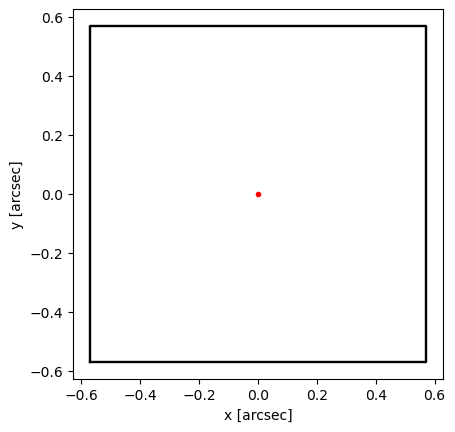

In [56]:
src_lms.plot()

In [57]:
cmd_lms = sim.UserCommands(
    use_instrument="METIS",
    set_modes=['lms'],
    properties={
        "!OBS.wavelen": 3.555,

        # These !SIM.spectral_* properties make the simulation faster, but less precise.
        # Comment them out for your final simulations.
        #"!SIM.spectral_bin_width": 1e-3,
        #"!SIM.spectral_resolution": 1000,
       
    })

metis_lms = sim.OpticalTrain(cmd_lms)
metis_lms['skycalc_atmosphere'].include=False

In [58]:
metis_lms.observe(src_lms)

 FOV effects:  50%|██████████████████████████████████▌                                  | 1/2 [02:22<02:22, 142.45s/it]

astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 1
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 2
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 3
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 4
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 5
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 6
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 7
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 8
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 9
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 10
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 11
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 12
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 13
astar.scopesim.effects.spectral_trace_list_utils - Mapping Slice 14
astar.scopesim.effects.spectral_trace_list_utils - Mappin


 FOVs: 100%|████████████████████████████████████████████████████████████████████████████| 1/1 [03:58<00:00, 238.02s/it]
 Image Plane effects: 0it [00:00, ?it/s]


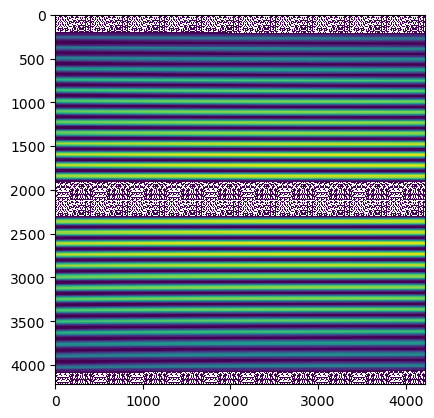

In [59]:
ip = metis_lms.image_planes[0]

plt.imshow(ip.data, norm=LogNorm())

In [60]:
hdul_lms = metis_lms.readout(exptime=3600.)[0]

astar.scopesim.effects.electronic - WARNING: DIT = 1.000 s < MINDIT = 1.300 s
astar.scopesim.detector.detector_array - Extracting from 4 detectors...
astar.scopesim.effects.electronic - WARNING: Effect Quantization: 921539 negative pixels
astar.scopesim.effects.electronic - WARNING: Effect Quantization: 962451 negative pixels
astar.scopesim.effects.electronic - WARNING: Effect Quantization: 1039725 negative pixels
astar.scopesim.effects.electronic - WARNING: Effect Quantization: 993042 negative pixels
astar.scopesim.effects.electronic - WARNING: DIT = 1.000 s < MINDIT = 1.300 s


In [61]:
len(hdul_lms)

5

In [62]:
data_raw = hdul_lms[1].data

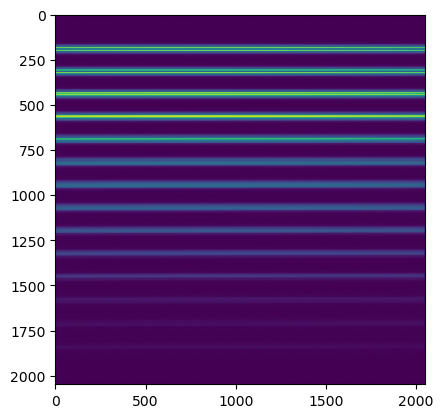

In [63]:
plt.imshow(data_raw)

In [64]:
rectified = metis_lms["lms_spectral_traces"].rectify_cube(hdul_lms)

astar.scopesim.effects.metis_lms_trace_list - Computing interpolation functions
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 1
astar.scopesim.effects.spectral_trace_list_utils -    3.53 .. 3.58 um
astar.scopesim.effects.spectral_trace_list_utils -    Bin width 1e-05 um
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 2
astar.scopesim.effects.spectral_trace_list_utils -    3.53 .. 3.58 um
astar.scopesim.effects.spectral_trace_list_utils -    Bin width 1e-05 um
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 3
astar.scopesim.effects.spectral_trace_list_utils -    3.53 .. 3.58 um
astar.scopesim.effects.spectral_trace_list_utils -    Bin width 1e-05 um
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 4
astar.scopesim.effects.spectral_trace_list_utils -    3.53 .. 3.58 um
astar.scopesim.effects.spectral_trace_list_utils -    Bin width 1e-05 um
astar.scopesim.effects.spectral_trace_list_utils - Rectifying Slice 

In [65]:
rectified.data.shape

(5517, 28, 110)

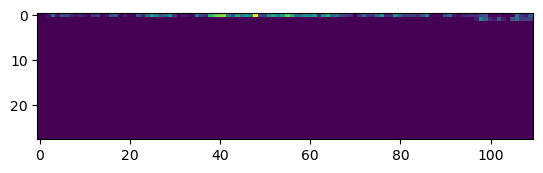

In [66]:
plt.imshow(rectified.data[3,:,:])

Text(0, 0.5, 'slice number')

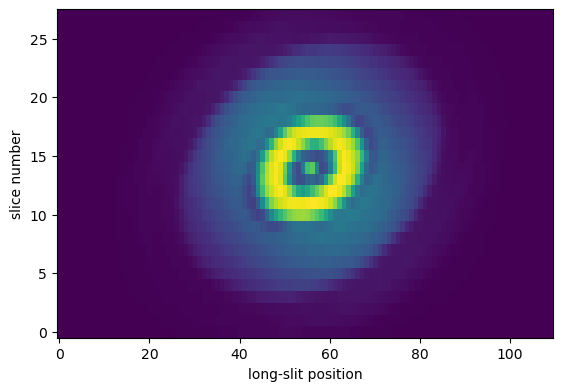

In [67]:
plt.imshow(rectified.data.sum(axis=0), aspect=2.6, origin='lower')
plt.xlabel('long-slit position')
plt.ylabel('slice number')